In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline

In [54]:
df = pd.read_csv('Life_Expectancy_Data.csv')
df.shape

(2938, 22)

In [55]:
df.dtypes

Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [56]:
df.dtypes[df.isna().sum()>0]

Life expectancy                    float64
Adult Mortality                    float64
Alcohol                            float64
Hepatitis B                        float64
 BMI                               float64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [57]:
df.columns = df.columns.str.replace(' ', '')
df.columns


Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='str')

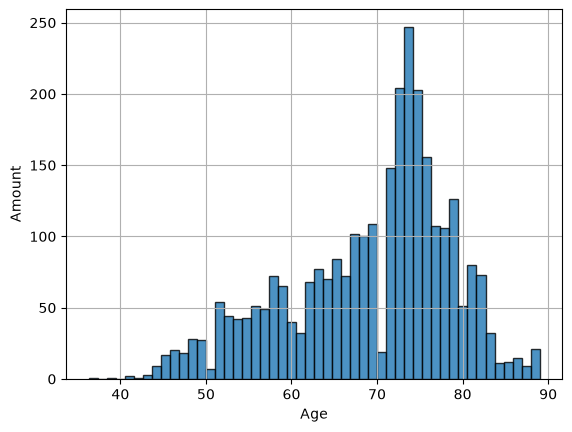

In [58]:
df['Lifeexpectancy'].hist(bins=50, edgecolor='black', alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Amount')
plt.show()

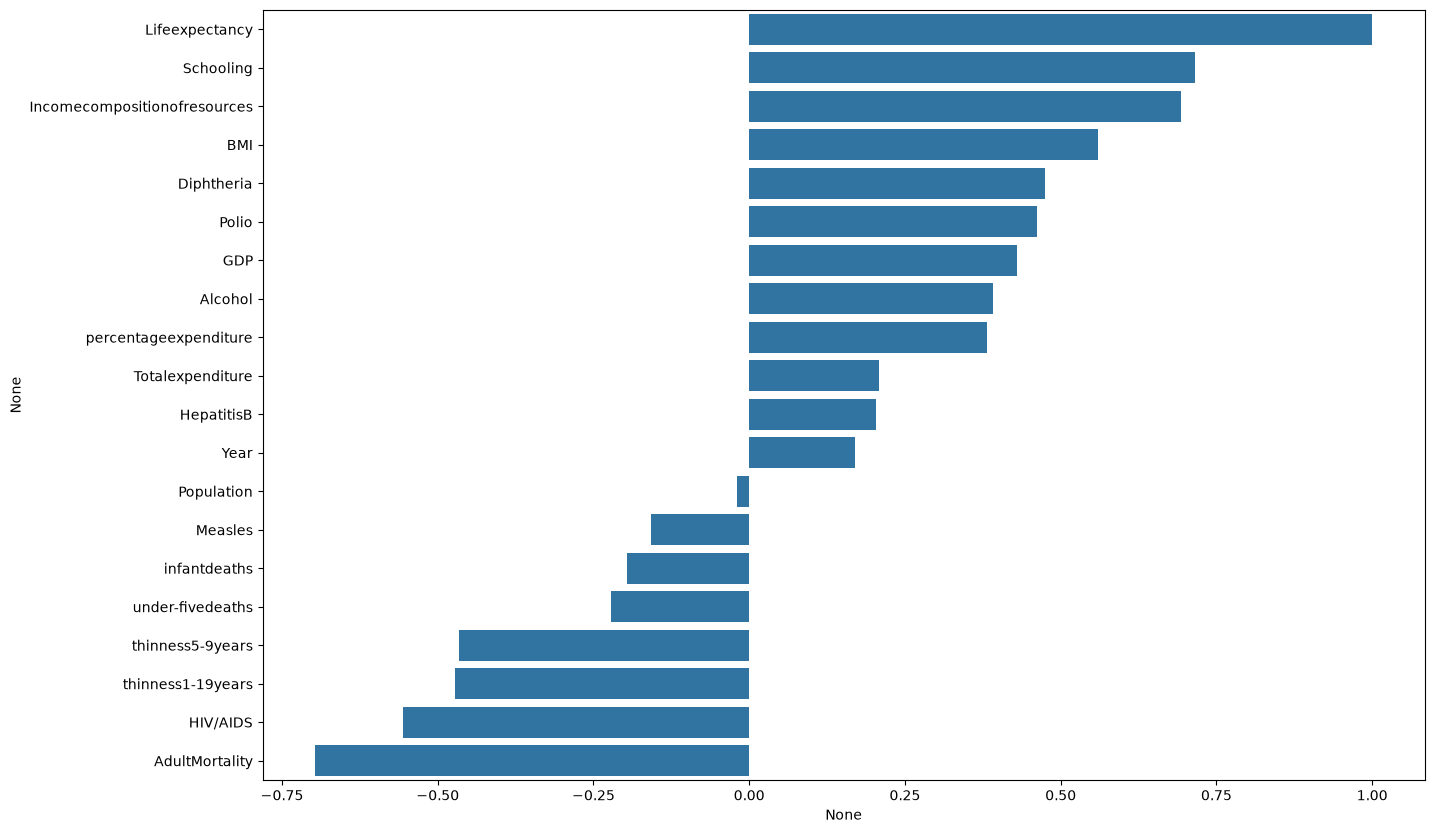

In [59]:
numeric_data = df.select_dtypes([np.number])
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

df = df.fillna(numeric_data_mean)
corr = df[numeric_features].corrwith(df['Lifeexpectancy']).sort_values(ascending=False)
plot = sns.barplot(y=corr.index, x=corr)
plot.figure.set_size_inches(15,10)

In [60]:
df[numeric_features].columns

Index(['Year', 'Lifeexpectancy', 'AdultMortality', 'infantdeaths', 'Alcohol',
       'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
       'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='str')

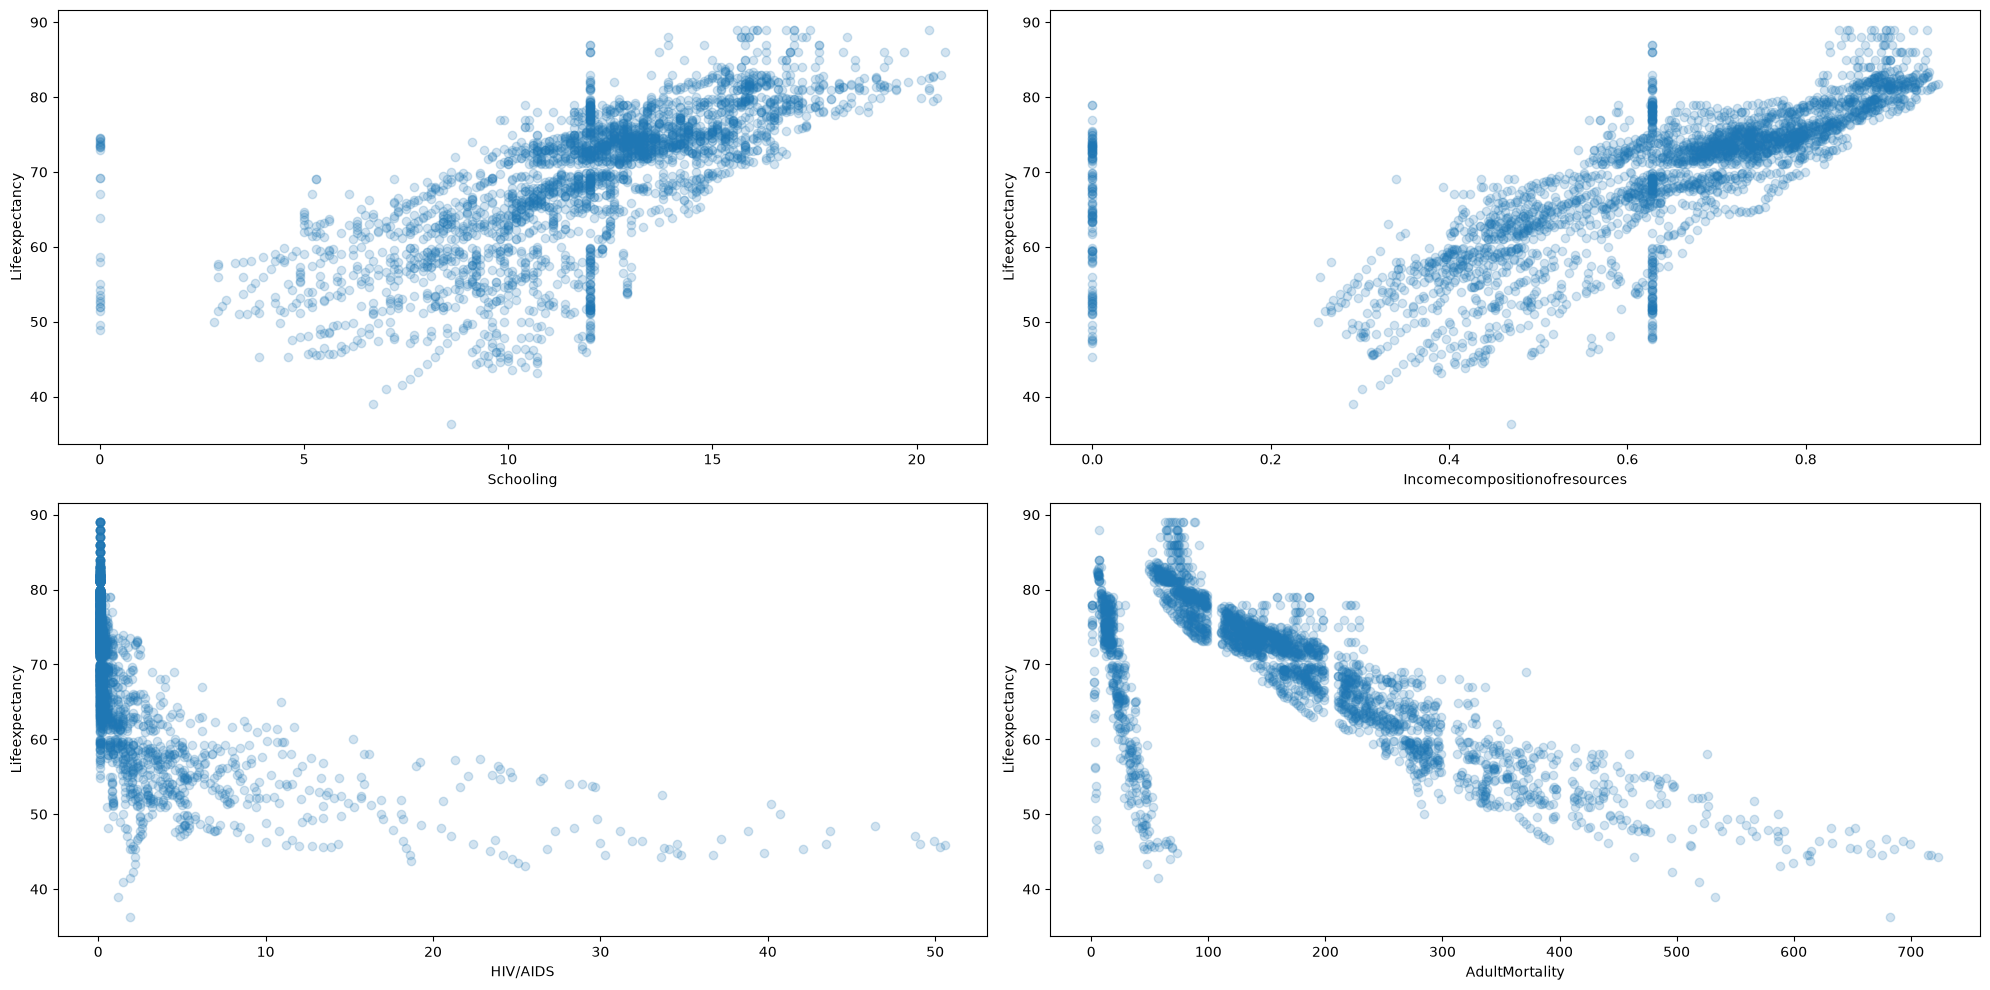

In [61]:
fig, axs = plt.subplots(figsize=(20,10), nrows=2 ,ncols=2)
for i, feature in enumerate(['Schooling','Incomecompositionofresources', 'HIV/AIDS', 'AdultMortality']):
    axs[i//2, i%2].scatter(df[feature], df['Lifeexpectancy'], alpha=0.2)
    axs[i//2, i%2].set_xlabel(feature)
    axs[i//2, i%2].set_ylabel('Lifeexpectancy')
plt.tight_layout()

In [62]:
from sklearn.model_selection import train_test_split

X = df.drop('Lifeexpectancy', axis=1)
y = df['Lifeexpectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)


In [63]:
numeric_features = numeric_features.drop('Lifeexpectancy')
numeric_features

Index(['Year', 'AdultMortality', 'infantdeaths', 'Alcohol',
       'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
       'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='str')

In [64]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error

model_ridge = Ridge()
model_lasso = Lasso()

model_ridge.fit(X_train[numeric_features], y_train)
y_pred_ridge = model_ridge.predict(X_train[numeric_features])

model_lasso.fit(X_train[numeric_features], y_train)
y_pred_lasso = model_lasso.predict(X_train[numeric_features])

print('Ridge. Train RMSE = %.4f' % root_mean_squared_error(y_train,y_pred_ridge))
print('Ridge. Train R^2 = %.4f' % r2_score(y_train, y_pred_ridge))

print('Lasso. Train RMSE = %.4f' % root_mean_squared_error(y_train,y_pred_lasso))
print('Lasso. Train R^2 = %.4f' % r2_score(y_train, y_pred_lasso))

Ridge. Train RMSE = 4.1261
Ridge. Train R^2 = 0.8168
Lasso. Train RMSE = 4.2290
Lasso. Train R^2 = 0.8075


/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.293335576321448e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.496639e+04, tolerance: 1.910e+01
  model = cd_fast.enet_coordinate_descent(


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

model_ridge = Ridge()
model_lasso = Lasso()

model_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = model_ridge.predict(X_train_scaled)

model_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = model_lasso.predict(X_train_scaled)

print('Ridge. Train RMSE = %.4f' % root_mean_squared_error(y_train,y_pred_ridge))
print('Ridge. Train R^2 = %.4f' % r2_score(y_train, y_pred_ridge))

print('Lasso. Train RMSE = %.4f' % root_mean_squared_error(y_train,y_pred_lasso))
print('Lasso. Train R^2 = %.4f' % r2_score(y_train, y_pred_lasso))

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:

from sklearn.pipeline import Pipeline

In [ ]:
#df = pd.get_dummies(df, columns=df.select_dtypes(include=['str']).columns)